## Name: Naveed Alboudwarej 
## USC ID: 8695198359

 Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS,poly
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

Get the Cycle Power Plant Data Set

In [2]:
df= pd.read_excel("Folds5x2_pp.xlsx",sheet_name="Sheet1")

### (b) Exploring the data

#### i. rows and columns

In [3]:
print(df.head())
print(df.shape)

      AT      V       AP     RH      PE
0  14.96  41.76  1024.07  73.17  463.26
1  25.18  62.96  1020.04  59.08  444.37
2   5.11  39.40  1012.16  92.14  488.56
3  20.86  57.32  1010.24  76.64  446.48
4  10.82  37.50  1009.23  96.62  473.90
(9568, 5)


9,568 rows, 5 columns. Rows = hourly plant readings. Columns = 4 predictors (AT, V, AP, RH) and 1 response (PE).

#### ii. pairwise scatterplots of all the varianbles

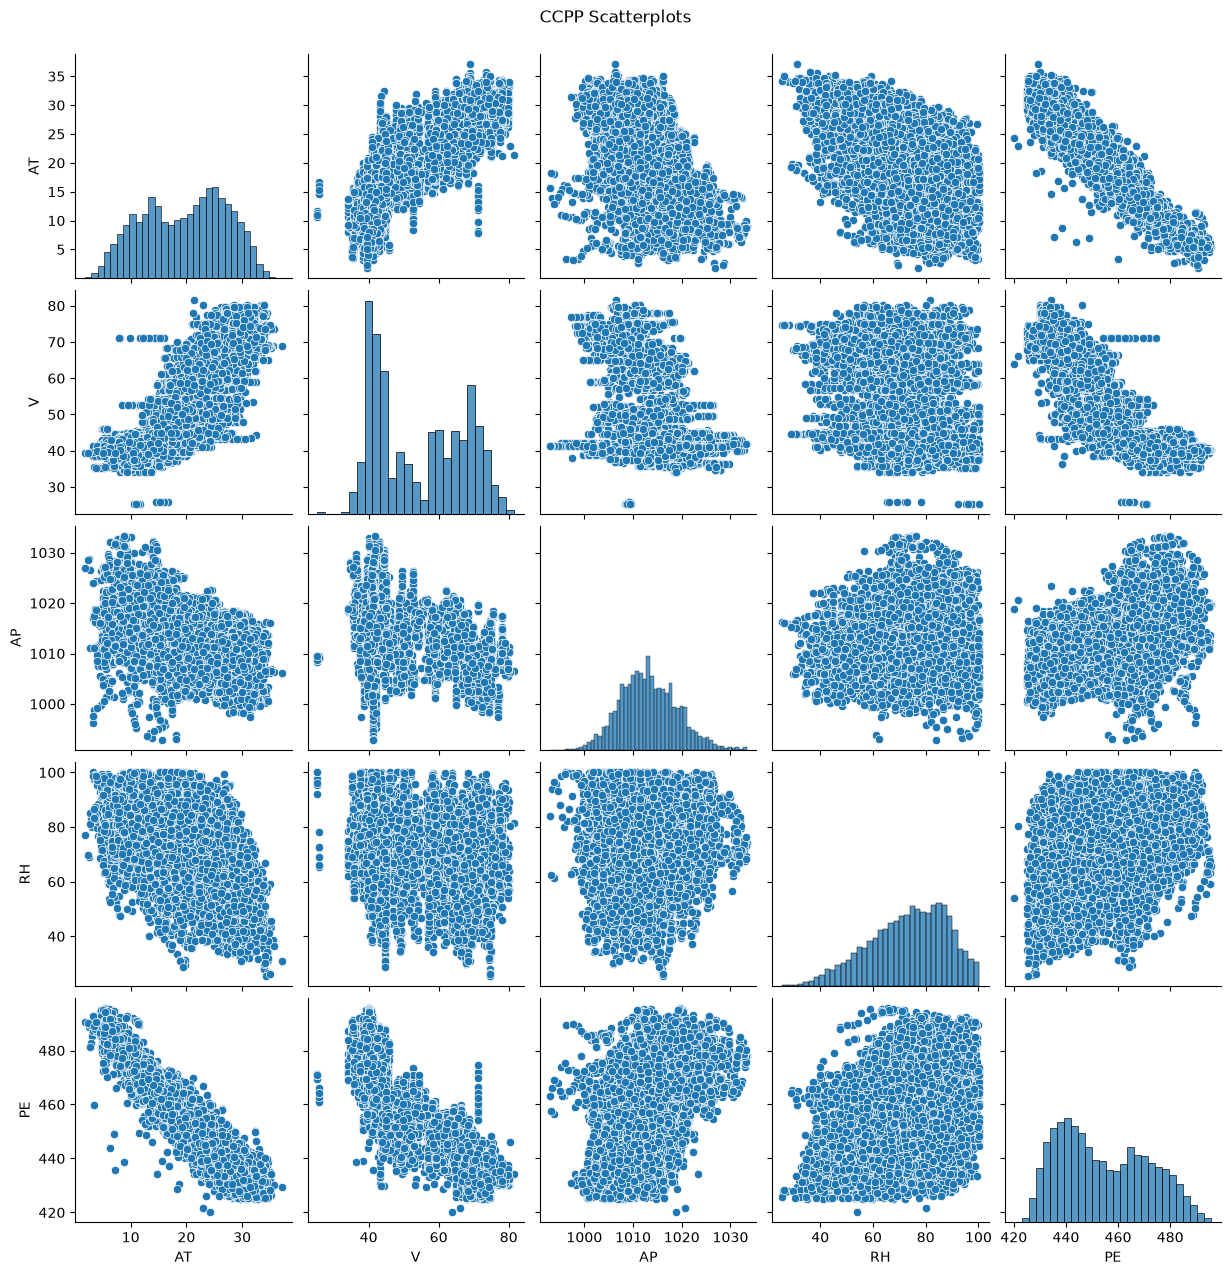

In [4]:
var= ["AT","V","AP","RH","PE"]
plot= sns.pairplot(df,vars=var)
plot.figure.suptitle("CCPP Scatterplots",y=1.02)
plt.show()

AT and V both have strong negative relationships with PE. AP and RH have weaker positive ones. AT and V are correlated with each other.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [5]:
summary= pd.DataFrame({
    "mean": df.mean(),
    "median": df.median(),
    "range": df.max()-df.min(),
    "q1": df.quantile(0.25),
    "q3": df.quantile(0.75),
    "IQR": df.quantile(0.75)-df.quantile(0.25)
})
summary

,mean,median,range,q1,q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


Looking at the summary statistics, the means and medians are fairly close for all five variables, suggesting the data isn't heavily skewed. Ambient pressure sits on a very different scale than the others, in the thousands, while the rest are all in the tens to low hundreds. Humidity has the widest spread between its first and third quartiles, while ambient pressure has the tightest.

### (c) Simple Linear Regression

In [6]:
predictors= ["AT","V","AP","RH"]
simple_results= {}
summary_rows= []

for p in predictors:
    design= MS([p])
    X= design.fit_transform(df)
    y= df["PE"]
    results= sm.OLS(y,X).fit()
    simple_results[p]= results
    summary_rows.append({
        "Predictor": p,
        "Intercept": results.params["intercept"],
        "Coefficient": results.params[p],
        "P-value": results.pvalues[p],
        "R-squared": results.rsquared
    })

pd.DataFrame(summary_rows)

,Predictor,Intercept,Coefficient,P-value,R-squared
0,AT,497.034120,-2.171320,0.0,0.898948
1,V,517.801526,-1.168135,0.0,0.756518
2,AP,-1055.260989,1.489872,0.0,0.268769
3,RH,420.961766,0.455650,0.0,0.151939


All four predictors show a statistically significant association with PE, each with a p-value of essentially 0. R squared varies a lot though: AT explains about 89.9% of the variance on its own, V about 75.7%, AP about 26.9%, and RH only about 15.2%.

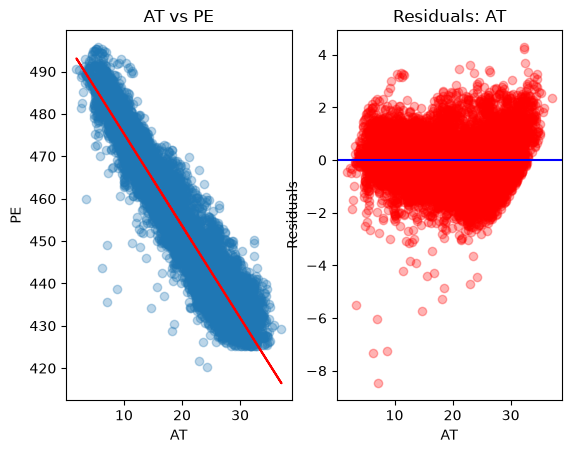

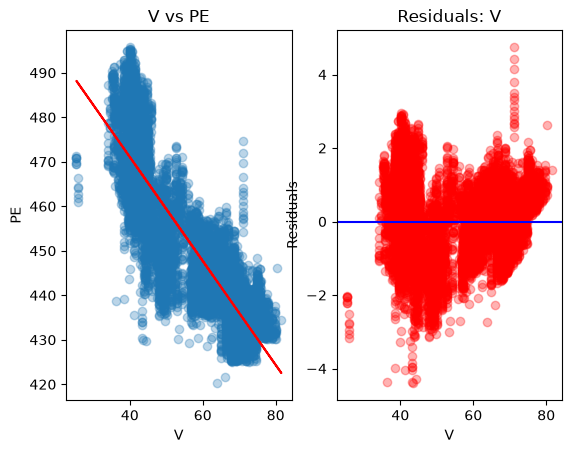

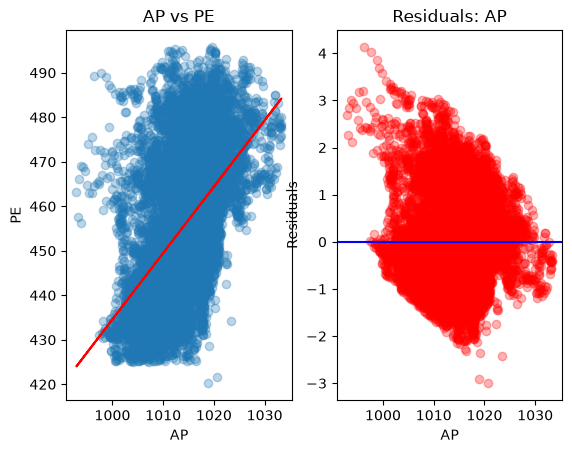

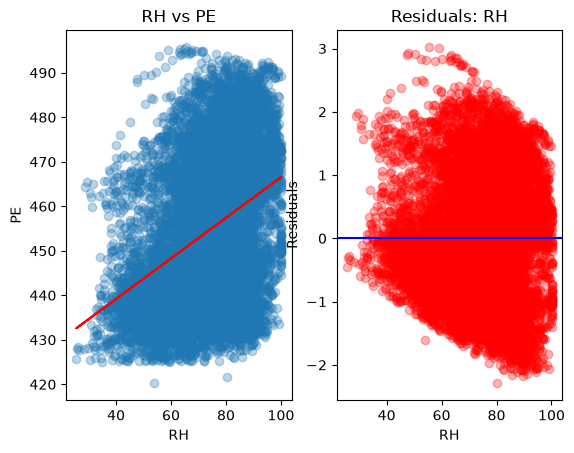

In [7]:
target= "PE"

for col in predictors:
    model= simple_results[col]
    y= df[target]

    fig,axes= subplots(nrows=1,ncols=2)

    axes[0].scatter(df[col],y,alpha=0.3)
    axes[0].plot(df[col],model.fittedvalues,color="red")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel(target)
    axes[0].set_title(f"{col} vs {target}")

    student_resid= model.get_influence().resid_studentized_internal
    axes[1].scatter(df[col],student_resid,color="red",alpha=0.3)
    axes[1].axhline(0,color="blue")
    axes[1].set_xlabel(col)
    axes[1].set_ylabel("Residuals")
    axes[1].set_title(f"Residuals: {col}")

In [8]:
outlier_rows= []

for p in predictors:
    results= simple_results[p]
    infl= results.get_influence()
    student_resid= infl.resid_studentized_internal

    is_outlier= np.abs(student_resid)>3
    outlier_count= int(is_outlier.sum())

    outlier_rows.append({
        "Predictor": p,
        "Studentized Residual > 3": outlier_count,
        "Max Cooks Distance": infl.cooks_distance[0].max()
    })

pd.DataFrame(outlier_rows)

,Predictor,Studentized Residual > 3,Max Cooks Distance
0,AT,42,0.014325
1,V,33,0.003243
2,AP,29,0.008152
3,RH,2,0.002059


Outlier counts based on studentized residuals above 3 are 42 for AT, 33 for V, 29 for AP, and 2 for RH. Max Cook's distance stays low across all four predictors, topping out at 0.0143 for AT. Since no point comes close to a concerning influence level, there isn't strong justification for removing any specific observations.

### (d) Multiple Regression

In [9]:
X= MS(predictors).fit_transform(df)
y= df["PE"]
model= sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:40:39   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    454.6093      9.749     46.634      0.0

R squared is 0.929, so the four predictors together explain about 92.9% of the variance in PE. All four are statistically significant (p = 0.000 for AT, V, AP, and RH), so H0 is rejected for each.

### (e) 1c Compare to 1d

Text(0.5, 1.0, 'Simple vs Multiple Regression Coefficients')

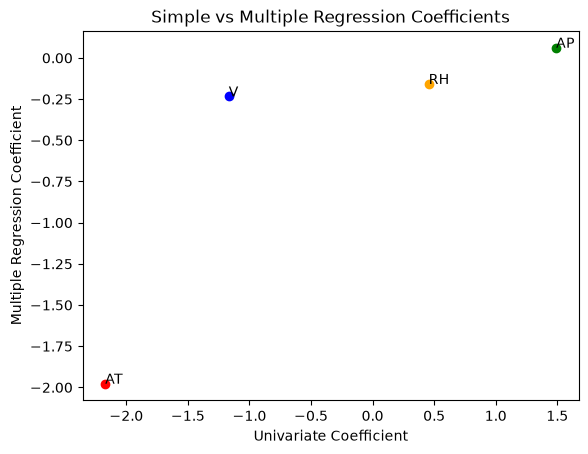

In [10]:
colors= {"AT":"red","V":"blue","AP":"green","RH":"orange"}

fig,ax= subplots()

for col in predictors:
    uni= simple_results[col].params[col]
    multi= model.params[col]
    ax.scatter(uni,multi,color=colors[col])
    ax.annotate(col,(uni,multi))

ax.set_xlabel("Univariate Coefficient")
ax.set_ylabel("Multiple Regression Coefficient")
ax.set_title("Simple vs Multiple Regression Coefficients")

The coefficients shrink noticeably from simple to multiple regression, most sharply for AP (1.490 down to 0.062) and RH, which flips sign entirely (0.456 up front, negative 0.158 in the full model). That flip happens because RH is correlated with the other predictors, so its solo coefficient was partly capturing their effect too.

### (f) Nonlinear Association

In [11]:
poly_results= []

for col in predictors:
    X_cubic= MS([poly(col,degree=3)]).fit_transform(df)
    results_cubic= sm.OLS(y,X_cubic).fit()
    poly_results.append(results_cubic)
    print(results_cubic.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:40:40   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept               454.36

AT, V, and AP all show clear evidence of a nonlinear relationship, with significant squared and cubed terms. RH is weaker; its squared term isn't significant (p = 0.214), though its cubed term is (p < 0.001).

### (g) Interactions of Predictors

In [12]:
terms= predictors+[("AT","V"),("AT","AP"),("AT","RH"),("V","AP"),("V","RH"),("AP","RH")]

X= MS(terms).fit_transform(df)
interaction_results= sm.OLS(y,X).fit()
print(interaction_results.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:40:40   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    685.7825     78.640      8.721      0.0

Significant interactions: AT:V, AT:RH, V:AP, and AP:RH. Not significant: AT:AP (p = 0.452) and V:RH (p = 0.086).

### (h) Improvement

In [13]:
train_df,test_df= train_test_split(df,test_size=0.30,random_state=1)

In [14]:
X_train= MS(predictors).fit_transform(train_df)
X_test= MS(predictors).fit_transform(test_df)
y_train= train_df["PE"]
y_test= test_df["PE"]

baseline_model= sm.OLS(y_train,X_train).fit()

train_mse_baseline= mean_squared_error(y_train,baseline_model.predict(X_train))
test_mse_baseline= mean_squared_error(y_test,baseline_model.predict(X_test))

print("Baseline Train MSE:",train_mse_baseline)
print("Baseline Test MSE:",test_mse_baseline)

Baseline Train MSE: 20.766119761450934
Baseline Test MSE: 20.77747810688455


In [15]:
quad_terms= [poly("AT",degree=2),poly("V",degree=2),poly("AP",degree=2),poly("RH",degree=2)]

interaction_terms= [
    ("AT","V"),
    ("AT","AP"),
    ("AT","RH"),
    ("V","AP"),
    ("V","RH"),
    ("AP","RH")
]

full_terms= quad_terms+interaction_terms

design_full= MS(full_terms)
design_full= design_full.fit(train_df)

X_train_full= design_full.transform(train_df)
X_test_full= design_full.transform(test_df)

full_model= sm.OLS(y_train,X_train_full).fit()
print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7181.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:40:40   Log-Likelihood:                -19192.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6682   BIC:                         3.852e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept               578.41

In [16]:
reduced_terms= [poly("AT",degree=2),"V",poly("AP",degree=2),poly("RH",degree=2),("AT","V"),("AT","RH"),("AP","RH")]

design_reduced= MS(reduced_terms)
design_reduced= design_reduced.fit(train_df)

X_train_reduced= design_reduced.transform(train_df)
X_test_reduced= design_reduced.transform(test_df)

reduced_model= sm.OLS(y_train,X_train_reduced).fit()
print(reduced_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                 1.004e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:40:40   Log-Likelihood:                -19198.
No. Observations:                6697   AIC:                         3.842e+04
Df Residuals:                    6686   BIC:                         3.849e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
intercept               903.24

In [17]:
train_mse_reduced= mean_squared_error(y_train,reduced_model.predict(X_train_reduced))
test_mse_reduced= mean_squared_error(y_test,reduced_model.predict(X_test_reduced))

print("Model 1 (All Predictors) - Train MSE:",train_mse_baseline,"Test MSE:",test_mse_baseline)
print("Model 2 (Reduced, Insignificant Terms Removed) - Train MSE:",train_mse_reduced,"Test MSE:",test_mse_reduced)

Model 1 (All Predictors) - Train MSE: 20.766119761450934 Test MSE: 20.77747810688455
Model 2 (Reduced, Insignificant Terms Removed) - Train MSE: 18.09323565111255 Test MSE: 18.263588113260237


For the model using all predictors, train MSE was 20.766 and test MSE was 20.777. After building the second model with the significant interaction and quadratic terms, train MSE dropped to 18.093 and test MSE dropped to 18.264, a clear improvement.

### (i) KNN

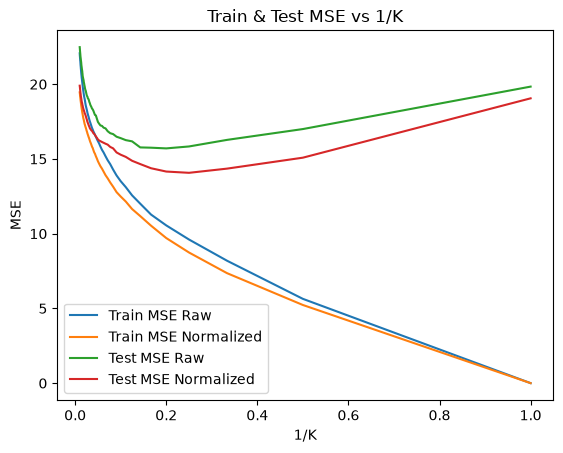

In [18]:
Kvalues= np.arange(1,101)

train_error_raw= []
test_error_raw= []
train_error_norm= []
test_error_norm= []

x_train= train_df[predictors]
x_test= test_df[predictors]

scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_test_scaled= scaler.transform(x_test)

for k in Kvalues:
    knn= KNeighborsRegressor(n_neighbors=k)
    train_prediction= knn.fit(x_train,y_train).predict(x_train)
    test_prediction= knn.predict(x_test)
    train_error_raw.append(mean_squared_error(y_train,train_prediction))
    test_error_raw.append(mean_squared_error(y_test,test_prediction))

for k in Kvalues:
    knn= KNeighborsRegressor(n_neighbors=k)
    train_prediction= knn.fit(x_train_scaled,y_train).predict(x_train_scaled)
    test_prediction= knn.predict(x_test_scaled)
    train_error_norm.append(mean_squared_error(y_train,train_prediction))
    test_error_norm.append(mean_squared_error(y_test,test_prediction))

inv_k= 1.0/Kvalues

fig,ax= subplots()
ax.plot(inv_k,train_error_raw,label="Train MSE Raw")
ax.plot(inv_k,train_error_norm,label="Train MSE Normalized")
ax.plot(inv_k,test_error_raw,label="Test MSE Raw")
ax.plot(inv_k,test_error_norm,label="Test MSE Normalized")
ax.set_title("Train & Test MSE vs 1/K")
ax.set_xlabel("1/K")
ax.set_ylabel("MSE")
ax.legend()

In [19]:
best_k_raw= Kvalues[np.argmin(test_error_raw)]
best_k_norm= Kvalues[np.argmin(test_error_norm)]

print("Best k (Raw):",best_k_raw,"Test MSE:",min(test_error_raw))
print("Best k (Normalized):",best_k_norm,"Test MSE:",min(test_error_norm))

Best k (Raw): 5 Test MSE: 15.704821203761764
Best k (Normalized): 4 Test MSE: 14.070606067136888


For KNN using raw features, the best k was 5, giving a test MSE of 15.705. Using normalized features, the best k was 4, giving a test MSE of 14.071. Normalization clearly helps here.

### (j ) Compare KNN and Linear

In [20]:
best_test_mse_raw= min(test_error_raw)
best_test_mse_norm= min(test_error_norm)

print("Best KNN Test MSE (Raw):",best_test_mse_raw)
print("Best KNN Test MSE (Normalized):",best_test_mse_norm)
print("Model 1 (All Predictors) Test MSE:",test_mse_baseline)
print("Model 2 (Reduced) Test MSE:",test_mse_reduced)

Best KNN Test MSE (Raw): 15.704821203761764
Best KNN Test MSE (Normalized): 14.070606067136888
Model 1 (All Predictors) Test MSE: 20.77747810688455
Model 2 (Reduced) Test MSE: 18.263588113260237


The best KNN result (14.071) outperforms both linear models, the full model with all predictors (20.777) and the reduced model with the significant interaction and quadratic terms (18.264). This suggests KNN captures the underlying relationship better than either linear approach in this case.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

It would be better because, with a lot of data and little amount of predictors a more flexible model can capture the actual pattern without overfitting.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

It would be worse because, with few observations and a lot of predictors, a flexible model would fit noise instead of the actual structure.

### (c) The relationship between the predictors and response is highly non-linear.

It would be better because, a rigid model cant bend to fit a non linear relatiobship so, flexibility helps reduce the bias. 

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

It would be worse because, when the error variance is already high a flexible model would also fit the noise which ultimatley hurts the test performance.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

- obs 1 = 3
- obs 2 = 2
- obs 3 = 3.162
- obs 4 = 2.236
- obs 5 = 1.414
- obs 6 = 1.732

### (b) What is our prediction with K = 1? Why?

K=1 -> Green thus obs 5 is the closest point at 1.414 and the Y is green

### (c) What is our prediction with K = 3? Why?

K=3 -> Red because the three closest are obs 5 which is green , obs 6 which is red and obs 2 which is red and majority is red so its red

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

The best value for K would be smaller because a small K value is what allows for a KNN to be flexible